In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  str    
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  str    
 3   education_level          32424 non-null  str    
 4   employment_status        32424 non-null  str    
 5   job_title                32424 non-null  str    
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  str    
 10  loan_type                12995 non-null  str    
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct   32424 no

In [19]:
df_clean['is_good_credit'].value_counts()

is_good_credit
0    20553
1    11871
Name: count, dtype: int64

1. Data Prepared. Downstream Task: Predicting 'is_good_credit'
2. Injected 30% missing values into 'education_level'
3. Performing Imputations (Mode, KNN, Iterative)...
4. Training Downstream ML Models and Evaluating...

=== Downstream ML Performance Comparison (F1-Score) ===


Dataset Version,1. Ground Truth (No Missing),2. Mode Imputed,3. KNN Imputed,4. Iterative Imputed
ML Model,,,,
Logistic Regression,0.0008,0.0008,0.0008,0.0008
Naive Bayes,0.0833,0.0908,0.0908,0.0908
Random Forest,0.0942,0.1015,0.1053,0.1015



=== Detailed Results ===


,Dataset Version,ML Model,Accuracy,Precision,Recall,F1-Score
0,1. Ground Truth (No Missing),Logistic Regression,0.6338,0.3333,0.0004,0.0008
3,2. Mode Imputed,Logistic Regression,0.6338,0.3333,0.0004,0.0008
6,3. KNN Imputed,Logistic Regression,0.6338,0.3333,0.0004,0.0008
9,4. Iterative Imputed,Logistic Regression,0.6338,0.3333,0.0004,0.0008
2,1. Ground Truth (No Missing),Naive Bayes,0.6234,0.3828,0.0468,0.0833
5,2. Mode Imputed,Naive Bayes,0.6231,0.3885,0.0514,0.0908
8,3. KNN Imputed,Naive Bayes,0.6234,0.3910,0.0514,0.0908
11,4. Iterative Imputed,Naive Bayes,0.6231,0.3885,0.0514,0.0908
1,1. Ground Truth (No Missing),Random Forest,0.6146,0.3377,0.0548,0.0942
4,2. Mode Imputed,Random Forest,0.6179,0.3646,0.0590,0.1015


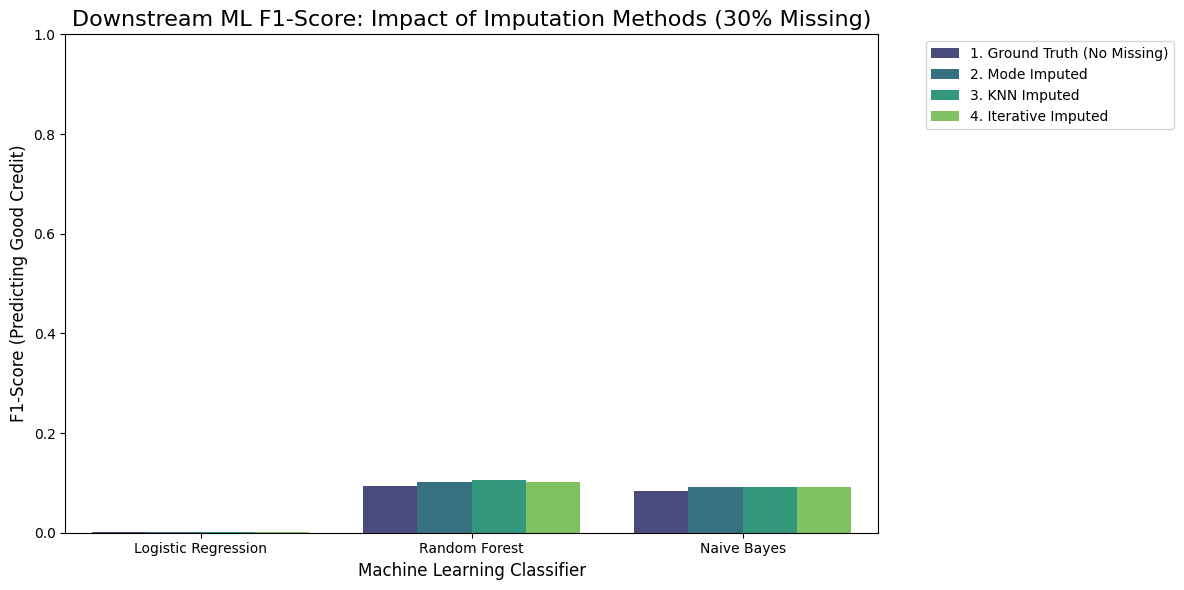

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Imputation Modules
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer 
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Machine Learning Modules
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ==========================================
# 1. Collect Data & Clean Data
# ==========================================
df = pd.read_csv('data/synthetic_personal_finance_dataset.csv')

# ตัดคอลัมน์ที่ไม่จำเป็น
df_clean = df.drop(columns=['user_id', 'record_date']).copy()

# สร้าง Downstream Target (Y สำหรับโมเดล ML สุดท้าย)
# สมมติโจทย์: ทำนายว่าลูกค้ามีเครดิตดีหรือไม่ (Credit Score >= 650 ถือว่าดี = 1, แย่ = 0)
df_clean['is_good_credit'] = (df_clean['credit_score'] >= 650).astype(int)

# ตัด credit_score เดิมทิ้ง เพื่อไม่ให้ ML โกงข้อสอบ
df_clean = df_clean.drop(columns=['credit_score'])

# คอลัมน์ที่เราจะเจาะรูและทำการ Impute
impute_target = 'education_level'
missing_rate = 0.3 # ทดสอบที่ Missing Rate 30% เพื่อความชัดเจน

print("1. Data Prepared. Downstream Task: Predicting 'is_good_credit'")

# ==========================================
# 2. Missing Injection (MCAR 30%)
# ==========================================
np.random.seed(42)
n_missing = int(len(df_clean) * missing_rate)
missing_indices = np.random.choice(df_clean.index, n_missing, replace=False)

df_simulated = df_clean.copy()
df_simulated.loc[missing_indices, impute_target] = np.nan

print(f"2. Injected 30% missing values into '{impute_target}'")

# ==========================================
# 3. Impute Data (สร้าง 3 Dataframes จาก 3 วิธี)
# ==========================================
print("3. Performing Imputations (Mode, KNN, Iterative)...")

# --- เตรียมข้อมูลสำหรับการทำ ML Imputation (Label Encoding ชั่วคราว) ---
df_for_impute = df_simulated.copy()
le_dict = {}
cat_cols = df_for_impute.select_dtypes(include=['object', 'string']).columns

# Encode ทุกคอลัมน์ที่เป็น Categorical เพื่อให้ KNN/Iterative ทำงานได้
for col in cat_cols:
    le = LabelEncoder()
    # เติมชั่วคราวเพื่อ fit
    le.fit(df_for_impute[col].dropna().astype(str).tolist() + ['Missing']) 
    le_dict[col] = le
    
    # หาตำแหน่งที่ไม่ได้เป็นค่าว่าง
    not_null_mask = df_for_impute[col].notnull()
    
    # สร้าง Series ใหม่ที่เป็นตัวเลข (float) เพื่อเลี่ยงปัญหา TypeError เมื่อกำหนดค่า int ทับ string
    encoded_col = pd.Series(np.nan, index=df_for_impute.index, dtype=float)
    encoded_col.loc[not_null_mask] = le.transform(df_for_impute.loc[not_null_mask, col].astype(str))
    
    # เขียนทับคอลัมน์เดิมด้วย Series ตัวเลข
    df_for_impute[col] = encoded_col

# Scale numerical
num_cols = df_for_impute.select_dtypes(include=np.number).columns.drop(['is_good_credit'])
scaler_impute = StandardScaler()
df_for_impute[num_cols] = scaler_impute.fit_transform(df_for_impute[num_cols])

# --- 3.1 Mode Imputed Dataset ---
df_mode = df_simulated.copy()
mode_val = df_mode[impute_target].mode()[0]
df_mode[impute_target] = df_mode[impute_target].fillna(mode_val)

# --- 3.2 KNN Imputed Dataset ---
knn_imputer = KNNImputer(n_neighbors=5)
df_knn_imputed_num = pd.DataFrame(knn_imputer.fit_transform(df_for_impute), columns=df_for_impute.columns)

df_knn = df_simulated.copy()
# แปลงตัวเลขกลับเป็น Category
imputed_knn_vals = np.round(df_knn_imputed_num.loc[missing_indices, impute_target]).astype(int)
imputed_knn_vals = np.clip(imputed_knn_vals, 0, len(le_dict[impute_target].classes_) - 1)
df_knn.loc[missing_indices, impute_target] = le_dict[impute_target].inverse_transform(imputed_knn_vals)

# --- 3.3 Iterative Imputed Dataset ---
iter_imputer = IterativeImputer(estimator=BayesianRidge(), random_state=42, max_iter=10)
df_iter_imputed_num = pd.DataFrame(iter_imputer.fit_transform(df_for_impute), columns=df_for_impute.columns)

df_iter = df_simulated.copy()
# แปลงตัวเลขกลับเป็น Category
imputed_iter_vals = np.round(df_iter_imputed_num.loc[missing_indices, impute_target]).astype(int)
imputed_iter_vals = np.clip(imputed_iter_vals, 0, len(le_dict[impute_target].classes_) - 1)
df_iter.loc[missing_indices, impute_target] = le_dict[impute_target].inverse_transform(imputed_iter_vals)

# เก็บ Dataset ทั้งหมดไว้ใน Dictionary
datasets = {
    '1. Ground Truth (No Missing)': df_clean,
    '2. Mode Imputed': df_mode,
    '3. KNN Imputed': df_knn,
    '4. Iterative Imputed': df_iter
}

# ==========================================
# 4 & 5. Using ML Model & Evaluate
# ==========================================
print("4. Training Downstream ML Models and Evaluating...\n")

# กำหนดโมเดลที่จะใช้ทดสอบ
ml_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Naive Bayes': GaussianNB()
}

results = []

# ฟังก์ชันเตรียมข้อมูลสำหรับเข้า ML สุดท้าย (One-Hot Encoding ดีกว่าสำหรับ LR และ NB)
def prep_for_ml(df_input):
    df_ml = df_input.copy()
    X = df_ml.drop(columns=['is_good_credit'])
    y = df_ml['is_good_credit']
    
    # One-Hot Encoding สำหรับ Categorical Variables
    X = pd.get_dummies(X, drop_first=True)
    
    # Standard Scale (Fit บน Train, Transform บน Test)
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ลูปทดสอบทุก Dataset x ทุก Model
for data_name, df_data in datasets.items():
    X_train, X_test, y_train, y_test = prep_for_ml(df_data)
    
    # Scale ข้อมูล (สำคัญสำหรับ Logistic Regression)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    for model_name, model in ml_models.items():
        # Train Model
        model.fit(X_train_scaled, y_train)
        
        # Predict
        y_pred = model.predict(X_test_scaled)
        
        # Evaluate
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        
        results.append({
            'Dataset Version': data_name,
            'ML Model': model_name,
            'Accuracy': acc,
            'Precision': prec,
            'Recall': rec,
            'F1-Score': f1
        })

# แสดงผลลัพธ์
df_results = pd.DataFrame(results)

# สร้าง Pivot Table เพื่อให้ดูง่ายขึ้น (เปรียบเทียบ F1-Score เป็นหลัก)
print("=== Downstream ML Performance Comparison (F1-Score) ===")
pivot_f1 = df_results.pivot(index='ML Model', columns='Dataset Version', values='F1-Score')
display(pivot_f1.round(4))

print("\n=== Detailed Results ===")
display(df_results.round(4).sort_values(by=['ML Model', 'Dataset Version']))

# พล็อตกราฟเปรียบเทียบ F1-Score
plt.figure(figsize=(12, 6))
sns.barplot(data=df_results, x='ML Model', y='F1-Score', hue='Dataset Version', palette='viridis')
plt.title('Downstream ML F1-Score: Impact of Imputation Methods (30% Missing)', fontsize=16)
plt.ylabel('F1-Score (Predicting Good Credit)', fontsize=12)
plt.xlabel('Machine Learning Classifier', fontsize=12)
plt.ylim(0.0, 1.0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()